In [ ]:
!pip install bayesian-optimization

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from bayes_opt import BayesianOptimization

In [10]:
df = pd.read_csv('clean_df (1).csv')
df.shape

(2927, 117)

<Axes: xlabel='SalePrice', ylabel='Count'>

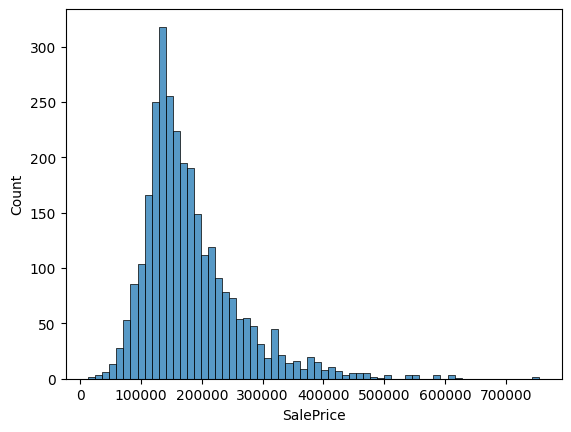

In [8]:
sns.histplot(df['SalePrice'])

In [34]:
growth_rate = 0.15   # growth per interval
first_interval_pct = 0.10  # first interval = e.g. 10% of max price

min_price = df['SalePrice'].min()
max_price = df['SalePrice'].max()

# initialize intervals
intervals = [min_price]

# first interval width
interval_width = max_price * first_interval_pct
current_boundary = min_price + interval_width
intervals.append(current_boundary)

# keep growing until we reach max_price
while current_boundary < max_price:
    interval_width *= (1 + growth_rate)  # increase width by 15%
    current_boundary += interval_width
    intervals.append(min(current_boundary, max_price))  # cap at max_price

# remove duplicates and sort
intervals = sorted(list(set(intervals)))

print("Calculated intervals:", intervals)

# create labels and assign intervals to df
labels = [f'Interval_{i+1}' for i in range(len(intervals) - 1)]
df['SalePrice_Interval'] = pd.cut(df['SalePrice'], bins=intervals, labels=labels, include_lowest=True)

# display counts
print(df['SalePrice_Interval'].value_counts().sort_index())


Calculated intervals: [12789, 88289.0, 175114.0, 274962.75, 389788.8125, 521838.78437499993, 673696.2520312499, 755000]
SalePrice_Interval
Interval_1     153
Interval_2    1550
Interval_3     896
Interval_4     254
Interval_5      59
Interval_6      13
Interval_7       2
Name: count, dtype: int64


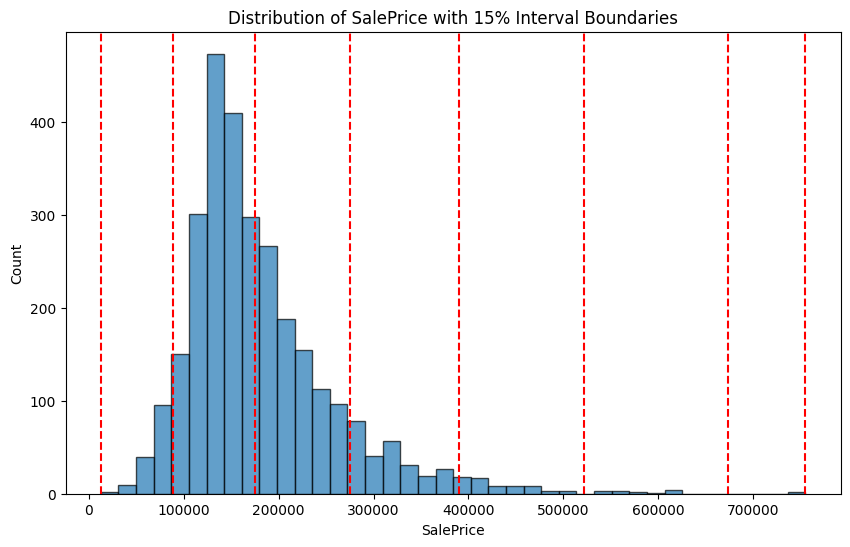

In [35]:
# Plot histogram with interval boundaries
plt.figure(figsize=(10, 6))
plt.hist(df['SalePrice'], bins=40, edgecolor='black', alpha=0.7)
for boundary in intervals:
    plt.axvline(boundary, color='red', linestyle='--')
plt.title("Distribution of SalePrice with 15% Interval Boundaries")
plt.xlabel("SalePrice")
plt.ylabel("Count")
plt.show()